In [1]:
# Imports
!pip install -q hopsworks pandas requests numpy matplotlib seaborn confluent-kafka xgboost tensorflow neuralforecast
import os
from dotenv import load_dotenv
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import hopsworks
from sklearn.multioutput import MultiOutputRegressor
from google.colab import userdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import xgboost as xgb
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

CITY = "Lahore"
DAYS_TO_FETCH    = 700
HOPSWORKS_API_KEY = userdata.get("hopscotch")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.3 MB/s eta 0:00:00
   

In [2]:
# fetching air quality data from open meteo
def get_city_coordinates(city_name):
    url = f"https://geocoding-api.open-meteo.com/v1/search?name={city_name}&count=1&format=json"
    response = requests.get(url)
    data = response.json()
    if "results" in data:
        return data["results"][0]["latitude"], data["results"][0]["longitude"], data["results"][0]["name"]
    else:
        raise ValueError(f"City '{city_name}' not found.")

lat, lon, city = get_city_coordinates(CITY)
print(f"Coordinates for {city}: Lat={lat}, Lon={lon}")

def fetch_aqi_data_openmeteo(lat, lon, days):
    end_date = datetime.now() - timedelta(days=5)
    start_date = end_date - timedelta(days=days)

    # meteo's api endpoint
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "us_aqi,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust",
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "timezone": "auto"
    }

    print(f"Air Quality data from {start_date.date()} to {end_date.date()}...")
    response = requests.get(url, params=params)
    data = response.json()

    if "hourly" not in data:
        raise ValueError(f"Open-Meteo AQI API Error: {data}")

    df = pd.DataFrame({
        "timestamp": pd.to_datetime(data["hourly"]["time"]),
        "us_aqi": data["hourly"]["us_aqi"],
        "pm25": data["hourly"]["pm2_5"],
        "pm10": data["hourly"]["pm10"],
        "co": data["hourly"]["carbon_monoxide"],
        "no2": data["hourly"]["nitrogen_dioxide"],
        "so2": data["hourly"]["sulphur_dioxide"],
        "o3": data["hourly"]["ozone"],
        "dust": data["hourly"]["dust"]
    })

    return df

df_aqi = fetch_aqi_data_openmeteo(lat, lon, DAYS_TO_FETCH)
print(f"Fetched {len(df_aqi)} records.")
display(df_aqi.head(10))

Coordinates for Lahore: Lat=31.558, Lon=74.35071
Air Quality data from 2024-09-02 to 2026-08-03...
Fetched 16824 records.


,timestamp,us_aqi,pm25,pm10,co,no2,so2,o3,dust
0,2024-09-02 00:00:00,113,69.8,102.4,1948.0,98.2,17.2,7.0,7.0
1,2024-09-02 01:00:00,116,67.5,99.7,1814.0,92.6,15.8,4.0,8.0
2,2024-09-02 02:00:00,120,65.0,95.9,1659.0,84.4,14.7,4.0,8.0
3,2024-09-02 03:00:00,123,61.0,90.1,1484.0,71.0,14.0,8.0,7.0
4,2024-09-02 04:00:00,126,57.7,85.4,1289.0,55.0,13.5,15.0,7.0
5,2024-09-02 05:00:00,129,56.0,82.2,1256.0,52.1,13.0,17.0,6.0
6,2024-09-02 06:00:00,131,50.3,73.8,1079.0,43.1,12.9,38.0,6.0
7,2024-09-02 07:00:00,133,46.2,68.0,833.0,30.5,12.8,67.0,7.0
8,2024-09-02 08:00:00,133,41.3,62.2,629.0,19.9,12.7,97.0,7.0
9,2024-09-02 09:00:00,134,39.7,61.2,511.0,13.4,12.8,126.0,8.0


In [3]:
# getting weather data for accurate prediction of next days as current air quality not enough to predict future.
def fetch_weather_data(lat, lon, days):
    end_date = datetime.now() - timedelta(days=5)
    start_date = end_date - timedelta(days=days)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation",
        "timezone": "auto"
    }

    print(f"Weather data from {start_date.date()} to {end_date.date()}...")
    response = requests.get(url, params=params)
    data = response.json()

    df = pd.DataFrame({
        "timestamp": pd.to_datetime(data["hourly"]["time"]),
        "temperature_c": data["hourly"]["temperature_2m"],
        "humidity_pct": data["hourly"]["relative_humidity_2m"],
        "wind_speed_kmh": data["hourly"]["wind_speed_10m"],
        "precipitation_mm": data["hourly"]["precipitation"]
    })

    return df

df_weather = fetch_weather_data(lat, lon, DAYS_TO_FETCH)

# merge aqi and weather df for 1 single df
df_raw = pd.merge(df_aqi, df_weather, on="timestamp", how="inner")
df_raw = df_raw.sort_values("timestamp").reset_index(drop=True)

print(f"Final raw dataset shape: {df_raw.shape}")
display(df_raw.head(10))

Weather data from 2024-09-02 to 2026-08-03...
Final raw dataset shape: (16824, 13)


,timestamp,us_aqi,pm25,pm10,co,no2,so2,o3,dust,temperature_c,humidity_pct,wind_speed_kmh,precipitation_mm
0,2024-09-02 00:00:00,113,69.8,102.4,1948.0,98.2,17.2,7.0,7.0,27.9,85,5.5,0.0
1,2024-09-02 01:00:00,116,67.5,99.7,1814.0,92.6,15.8,4.0,8.0,27.5,87,5.0,0.0
2,2024-09-02 02:00:00,120,65.0,95.9,1659.0,84.4,14.7,4.0,8.0,27.3,88,5.8,0.0
3,2024-09-02 03:00:00,123,61.0,90.1,1484.0,71.0,14.0,8.0,7.0,26.9,90,4.7,0.0
4,2024-09-02 04:00:00,126,57.7,85.4,1289.0,55.0,13.5,15.0,7.0,26.7,91,3.8,0.0
5,2024-09-02 05:00:00,129,56.0,82.2,1256.0,52.1,13.0,17.0,6.0,26.6,90,5.5,0.2
6,2024-09-02 06:00:00,131,50.3,73.8,1079.0,43.1,12.9,38.0,6.0,27.8,85,6.6,0.0
7,2024-09-02 07:00:00,133,46.2,68.0,833.0,30.5,12.8,67.0,7.0,28.6,85,6.6,0.0
8,2024-09-02 08:00:00,133,41.3,62.2,629.0,19.9,12.7,97.0,7.0,29.8,80,8.4,0.0
9,2024-09-02 09:00:00,134,39.7,61.2,511.0,13.4,12.8,126.0,8.0,30.2,77,11.2,0.0


In [4]:
def create_features(df, target_col="us_aqi"):
    df = df.copy()
    df = df.sort_values("timestamp").reset_index(drop=True)

    # -------------------------------------------------
    # 1. Calendar / Time features
    # -------------------------------------------------
    df["hour"] = df["timestamp"].dt.hour
    df["day"] = df["timestamp"].dt.day
    df["month"] = df["timestamp"].dt.month
    df["dayofweek"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # -------------------------------------------------
    # 2. Columns we want to create lags / rolling for
    # -------------------------------------------------
    pollutant_cols = ["pm25", "pm10", "co", "no2", "so2", "o3", "dust"]
    weather_cols   = ["temperature_c", "humidity_pct", "wind_speed_kmh", "precipitation_mm"]
    all_cols       = pollutant_cols + weather_cols + [target_col]

    # -------------------------------------------------
    # 3. Lag 1, Lag 24 and Trend (exactly as you wanted)
    # -------------------------------------------------
    for col in all_cols:
        df[f"{col}_lag_1"]  = df[col].shift(1)
        df[f"{col}_lag_24"] = df[col].shift(24)
        df[f"{col}_trend"]  = df[f"{col}_lag_1"] - df[f"{col}_lag_24"]

    # -------------------------------------------------
    # 4. Extra useful lags (recommended)
    # -------------------------------------------------
    extra_lags = [2, 3, 6, 12, 48, 72]
    for col in [target_col] + weather_cols:          # mainly for AQI + weather
        for lag in extra_lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

    # -------------------------------------------------
    # 5. Rolling means (24h) - as you requested
    # -------------------------------------------------
    for col in all_cols:
        df[f"{col}_rolling_24h"] = df[col].rolling(window=24, min_periods=1).mean()

    # -------------------------------------------------
    # 6. Extra strong features (help with under-prediction)
    # -------------------------------------------------
    # Rolling max (captures recent peaks)
    for window in [6, 12, 24]:
        df[f"{target_col}_max_{window}"] = df[target_col].rolling(window).max()

    # Short-term differences
    df[f"{target_col}_diff_1"] = df[target_col].diff(1)
    df[f"{target_col}_diff_3"] = df[target_col].diff(3)
    df[f"{target_col}_diff_6"] = df[target_col].diff(6)

    # Rolling std (volatility)
    df[f"{target_col}_std_24"] = df[target_col].rolling(24).std()

    # -------------------------------------------------
    # 7. Drop original current-hour columns
    #    (they are not available at prediction time)
    # -------------------------------------------------
    cols_to_drop = pollutant_cols + weather_cols
    df = df.drop(columns=cols_to_drop)

    # Remove rows with NaN created by lags/rolling
    df = df.dropna().reset_index(drop=True)

    return df


# -------------------------
# Usage
# -------------------------
df = create_features(df_raw)

print(f"Final shape: {df.shape}")
print("\nColumns created:")
print(df.columns.tolist())
display(df.head(8))

Final shape: (16752, 92)

Columns created:
['timestamp', 'us_aqi', 'hour', 'day', 'month', 'dayofweek', 'is_weekend', 'pm25_lag_1', 'pm25_lag_24', 'pm25_trend', 'pm10_lag_1', 'pm10_lag_24', 'pm10_trend', 'co_lag_1', 'co_lag_24', 'co_trend', 'no2_lag_1', 'no2_lag_24', 'no2_trend', 'so2_lag_1', 'so2_lag_24', 'so2_trend', 'o3_lag_1', 'o3_lag_24', 'o3_trend', 'dust_lag_1', 'dust_lag_24', 'dust_trend', 'temperature_c_lag_1', 'temperature_c_lag_24', 'temperature_c_trend', 'humidity_pct_lag_1', 'humidity_pct_lag_24', 'humidity_pct_trend', 'wind_speed_kmh_lag_1', 'wind_speed_kmh_lag_24', 'wind_speed_kmh_trend', 'precipitation_mm_lag_1', 'precipitation_mm_lag_24', 'precipitation_mm_trend', 'us_aqi_lag_1', 'us_aqi_lag_24', 'us_aqi_trend', 'us_aqi_lag_2', 'us_aqi_lag_3', 'us_aqi_lag_6', 'us_aqi_lag_12', 'us_aqi_lag_48', 'us_aqi_lag_72', 'temperature_c_lag_2', 'temperature_c_lag_3', 'temperature_c_lag_6', 'temperature_c_lag_12', 'temperature_c_lag_48', 'temperature_c_lag_72', 'humidity_pct_lag_2',

,timestamp,us_aqi,hour,day,month,dayofweek,is_weekend,pm25_lag_1,pm25_lag_24,pm25_trend,...,wind_speed_kmh_rolling_24h,precipitation_mm_rolling_24h,us_aqi_rolling_24h,us_aqi_max_6,us_aqi_max_12,us_aqi_max_24,us_aqi_diff_1,us_aqi_diff_3,us_aqi_diff_6,us_aqi_std_24
0,2024-09-05 00:00:00,112,0,5,9,3,0,54.9,37.7,17.2,...,3.637500,0.041667,127.166667,196.0,196.0,196.0,2.0,-52.0,-80.0,31.296154
1,2024-09-05 01:00:00,113,1,5,9,3,0,49.9,36.2,13.7,...,3.729167,0.041667,127.333333,185.0,196.0,196.0,1.0,-23.0,-83.0,31.205722
2,2024-09-05 02:00:00,114,2,5,9,3,0,45.8,35.2,10.6,...,3.837500,0.045833,127.583333,164.0,196.0,196.0,1.0,4.0,-71.0,31.067831
3,2024-09-05 03:00:00,115,3,5,9,3,0,42.1,34.2,7.9,...,4.087500,0.050000,127.875000,136.0,196.0,196.0,1.0,3.0,-49.0,30.908438
4,2024-09-05 04:00:00,115,4,5,9,3,0,38.0,33.6,4.4,...,4.345833,0.141667,128.166667,115.0,196.0,196.0,0.0,2.0,-21.0,30.745331
5,2024-09-05 05:00:00,115,5,5,9,3,0,31.8,36.8,-5.0,...,4.495833,0.145833,128.458333,115.0,196.0,196.0,0.0,1.0,5.0,30.578451
6,2024-09-05 06:00:00,116,6,5,9,3,0,43.3,38.3,5.0,...,4.354167,0.183333,128.833333,116.0,196.0,196.0,1.0,1.0,4.0,30.358247
7,2024-09-05 07:00:00,116,7,5,9,3,0,40.9,41.3,-0.4,...,4.320833,0.183333,129.208333,116.0,185.0,196.0,0.0,1.0,3.0,30.131565


In [5]:
HORIZON = 72

# Create t+1 ... t+72 targets
for h in range(1, HORIZON + 1):
    df[f"target_t+{h}"] = df["us_aqi"].shift(-h)

df = df.dropna().reset_index(drop=True)

# Feature columns (only past information)
feature_cols = [c for c in df.columns if c not in
                ["timestamp", "us_aqi", "pm25", "pm10", "co", "no2", "so2", "o3", "dust"]
                + [f"target_t+{h}" for h in range(1, HORIZON+1)]]

print("Number of features:", len(feature_cols))
print("Final dataset shape after feature engineering:", df.shape)

Number of features: 90
Final dataset shape after feature engineering: (16680, 164)


In [6]:
test_hours = 72
test_idx = len(df) - test_hours
split_idx = int(test_idx * 0.85)

train_df = df.iloc[:split_idx]
val_df   = df.iloc[split_idx:test_idx]
test_df  = df.iloc[test_idx:]

X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 14116 | Val: 2492 | Test: 72


In [7]:

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Evaluation:")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   MAE:  {mae:.2f}")
    print(f"   R²:   {r2:.4f}")
    return [rmse, r2, mae] , model


def plot_forecast(y_true, y_pred, title, timestamps=None):
    plt.figure(figsize=(14, 6))

    hours = range(1, 73)

    plt.plot(hours, y_true, label="Actual AQI", color="black", linewidth=2.5, marker="o", markersize=4)
    plt.plot(hours, y_pred, label="Predicted AQI", color="crimson", linewidth=2, marker="s", markersize=4, alpha=0.85)

    plt.title(title, fontsize=15, pad=12)
    plt.xlabel("Hours Ahead", fontsize=12)
    plt.ylabel("US AQI", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(0, 73, 6))

    # Add vertical lines to separate days
    plt.axvline(x=24, color="gray", linestyle="--", alpha=0.6, label="Day 1 → Day 2")
    plt.axvline(x=48, color="gray", linestyle="--", alpha=0.6, label="Day 2 → Day 3")

    plt.tight_layout()
    plt.show()

    # Also print error by day
    print(f"\n--- Error Breakdown ---")
    print(f"Day 1 (1-24h)  MAE: {mean_absolute_error(y_true[:24], y_pred[:24]):.2f}")
    print(f"Day 2 (25-48h) MAE: {mean_absolute_error(y_true[24:48], y_pred[24:48]):.2f}")
    print(f"Day 3 (49-72h) MAE: {mean_absolute_error(y_true[48:], y_pred[48:]):.2f}")

def predict_from_origin(origin_idx, models, feature_cols, df, horizon=72):
    feats = df.iloc[origin_idx][feature_cols].values.reshape(1, -1)
    return np.array([models[h].predict(feats)[0] for h in range(1, horizon + 1)])

In [8]:
# version 1 xgboost
models = {}
val_scores = []

for h in range(1, HORIZON + 1):
    target = f"target_t+{h}"

    y_train = train_df[target]
    y_val   = val_df[target]

    model = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=0.65,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=30
    )

    weights_train = np.clip(train_df["us_aqi"] / 100, 1.0, 5.0)

    model.fit(
        X_train, y_train,
        sample_weight=weights_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    models[h] = model

    # Quick validation score
    val_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, val_pred)
    val_scores.append(mae)

    if h % 4 == 0:
        print(f"Horizon t+{h:2d} | Val MAE: {mae:.2f}")

print("\nAverage Val MAE across all horizons:", np.mean(val_scores))

Horizon t+ 4 | Val MAE: 5.70
Horizon t+ 8 | Val MAE: 11.50
Horizon t+12 | Val MAE: 13.98
Horizon t+16 | Val MAE: 16.98
Horizon t+20 | Val MAE: 17.81
Horizon t+24 | Val MAE: 20.40
Horizon t+28 | Val MAE: 21.99
Horizon t+32 | Val MAE: 24.68
Horizon t+36 | Val MAE: 25.59
Horizon t+40 | Val MAE: 26.73
Horizon t+44 | Val MAE: 27.33
Horizon t+48 | Val MAE: 27.09
Horizon t+52 | Val MAE: 29.07
Horizon t+56 | Val MAE: 30.74
Horizon t+60 | Val MAE: 28.72
Horizon t+64 | Val MAE: 28.89
Horizon t+68 | Val MAE: 29.07
Horizon t+72 | Val MAE: 28.78

Average Val MAE across all horizons: 22.482640642692047


In [9]:
# last 72 hours
last_known_features = df.iloc[test_idx - 1][feature_cols].values.reshape(1, -1)

y_true = test_df["us_aqi"].values          # actual AQI of the 72 test hours
y_pred = []

for h in range(1, HORIZON + 1):
    pred = models[h].predict(last_known_features)[0]
    y_pred.append(pred)

y_pred = np.array(y_pred)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("\n===== Test Results (Last 72 hours) =====")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")


===== Test Results (Last 72 hours) =====
RMSE : 20.42
MAE  : 15.25
R²   : 0.1843


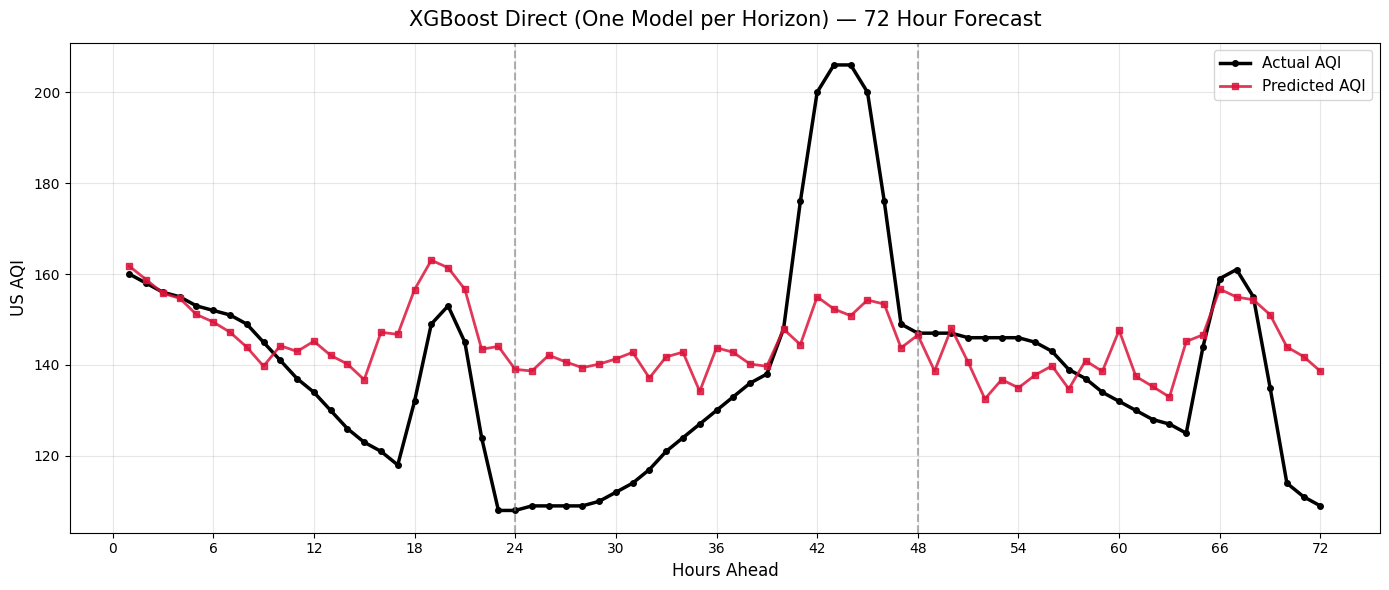


--- Error Breakdown ---
Day 1 (1-24h)  MAE: 11.76
Day 2 (25-48h) MAE: 23.71
Day 3 (49-72h) MAE: 10.26


In [10]:
# y_true and y_pred already exist from Version 1

plot_forecast(
    y_true,
    y_pred,
    title="XGBoost Direct (One Model per Horizon) — 72 Hour Forecast"
)

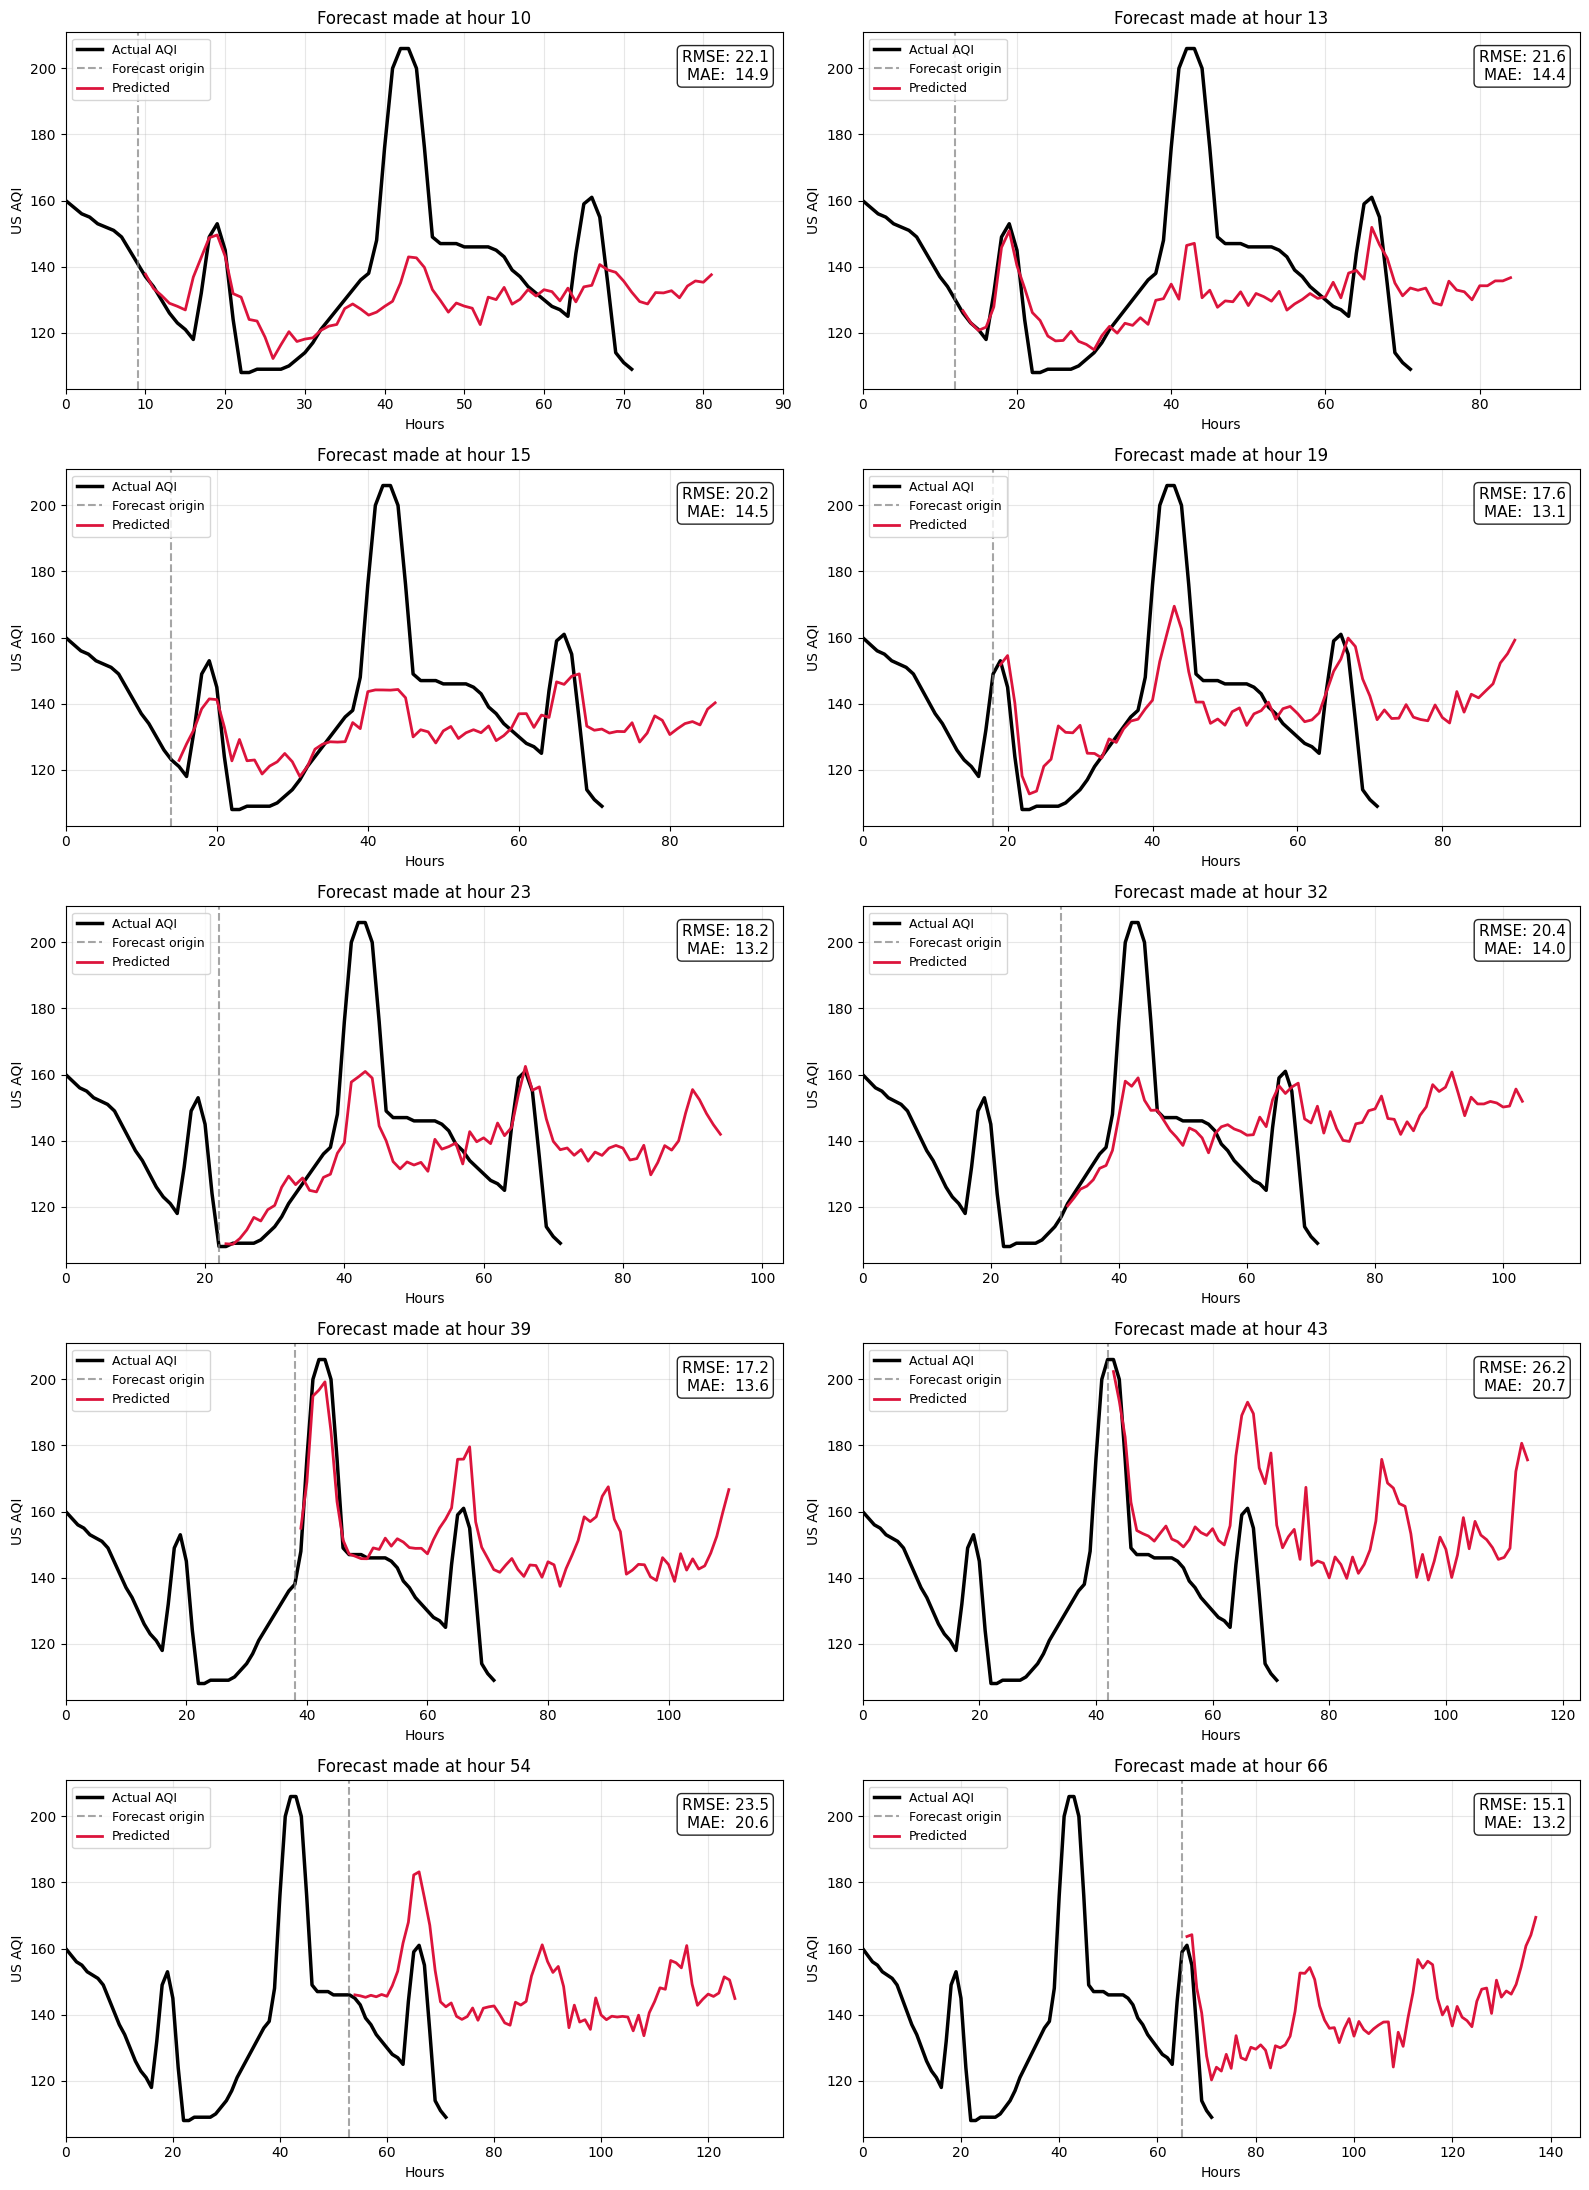


Summary of metrics (on remaining actual values):
  Offset |     RMSE |      MAE
------------------------------
      10 |     22.1 |     14.9
      13 |     21.6 |     14.4
      15 |     20.2 |     14.5
      19 |     17.6 |     13.1
      23 |     18.2 |     13.2
      32 |     20.4 |     14.0
      39 |     17.2 |     13.6
      43 |     26.2 |     20.7
      54 |     23.5 |     20.6
      66 |     15.1 |     13.2


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------------------------------------------------
# Settings
# -------------------------------------------------
HORIZON = 72
target_offsets = [10, 13, 15, 19, 23, 32, 39, 43, 54, 66] # random points

test_start = len(df) - HORIZON
actual_72 = df["us_aqi"].iloc[test_start:].values          # shape (72,)
x_actual = np.arange(HORIZON)

# -------------------------------------------------
# Generate forecasts + calculate metrics
# -------------------------------------------------
forecasts = {}
metrics = {}

for offset in target_offsets:
    origin = test_start + offset - 1
    preds = predict_from_origin(origin, models, feature_cols, df)
    forecasts[offset] = preds

    # Remaining actual values after the origin
    remaining_actual = actual_72[offset:]                  # from offset to 71
    remaining_pred = preds[:len(remaining_actual)]         # only the overlapping part

    if len(remaining_actual) > 0:
        rmse = np.sqrt(mean_squared_error(remaining_actual, remaining_pred))
        mae  = mean_absolute_error(remaining_actual, remaining_pred)
    else:
        rmse, mae = np.nan, np.nan

    metrics[offset] = (rmse, mae)

# -------------------------------------------------
# 5x2 Grid with metrics on each plot
# -------------------------------------------------
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for i, offset in enumerate(target_offsets):
    ax = axes[i]

    # Actual (last 72 hours)
    ax.plot(x_actual, actual_72, color="black", linewidth=2.5, label="Actual AQI")

    # Vertical line = forecast origin
    ax.axvline(offset - 1, color="gray", linestyle="--", alpha=0.7, label="Forecast origin")

    # Forecast line (full 72 steps into the future)
    forecast_x = np.arange(offset, offset + HORIZON)
    ax.plot(forecast_x, forecasts[offset], color="crimson", linewidth=2, label="Predicted")

    # Metrics
    rmse, mae = metrics[offset]
    metrics_text = f"RMSE: {rmse:.1f}\nMAE:  {mae:.1f}"

    ax.text(0.98, 0.95, metrics_text,
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    ax.set_title(f"Forecast made at hour {offset}", fontsize=12)
    ax.set_xlabel("Hours")
    ax.set_ylabel("US AQI")
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, offset + 80)

plt.tight_layout()
plt.show()

# Optional: print summary table
print("\nSummary of metrics (on remaining actual values):")
print(f"{'Offset':>8} | {'RMSE':>8} | {'MAE':>8}")
print("-" * 30)
for offset in target_offsets:
    rmse, mae = metrics[offset]
    print(f"{offset:>8} | {rmse:>8.1f} | {mae:>8.1f}")

In [12]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save all 72 horizon models + the feature list together
joblib.dump({
    "models": models,          # dict {1: model_h1, ..., 72: model_h72}
    "feature_cols": feature_cols,
    "horizon": HORIZON,
    "trained_at": datetime.now().isoformat()
}, "models/aqi_xgb_72h.joblib")

print("Saved.")

Saved.
